In [1]:
import google.auth
import numpy as np
import pandas as pd
import geopandas as gpd
from calitp_data_analysis import geography_utils
from calitp_data_analysis.sql import to_snakecase
from shared_utils import arcgis_query

In [2]:

import re
import pyarrow.parquet as pq
import gcsfs

In [3]:

import gc
import pandas as pd
import geopandas as gpd
from shapely.ops import unary_union


In [4]:
from calitp_data_analysis import get_fs
fs = get_fs()

In [5]:

import os
from typing import List, Optional, Union
import pyarrow.dataset as ds
from google.cloud import storage

In [6]:
import google.auth
import pandas_gbq

credentials, project = google.auth.default()
from functools import cache

from calitp_data_analysis.gcs_pandas import GCSPandas
from calitp_data_analysis.gcs_geopandas import GCSGeoPandas
from calitp_data_analysis.sql import to_snakecase

In [7]:
from typing import List

In [8]:
import geopandas as gpd
import pandas as pd

In [9]:
from functools import cache

from calitp_data_analysis.gcs_geopandas import GCSGeoPandas

@cache
def gcs_geopandas():
    return GCSGeoPandas()

In [10]:
@cache
def gcs_pandas():
    return GCSPandas()

In [11]:
gcsgp = GCSGeoPandas()

In [12]:
pd.options.display.max_columns = 100
pd.options.display.float_format = "{:.2f}".format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

# Census Blocks

In [13]:
census_block_url = "gs://calitp-analytics-data/data-analyses/equity_index/unbuffered_censusblocks_2020/combined_unbufferd_ca_2020.parquet"

In [14]:
census_df = to_snakecase(gcsgp.read_parquet(
   census_block_url)).to_crs(geography_utils.CA_NAD83Albers_m )

In [15]:
geography_utils.CA_NAD83Albers_m

'EPSG:3310'

In [16]:
census_df.shape

(519723, 19)

In [17]:
test_blocks = ['060750204024001', '060750260031011', '060750230032004']

In [18]:
sf_only = census_df.loc[census_df.geoid20.isin(test_blocks)]

In [19]:
sf_only.shape

(3, 19)

## HPMS

In [20]:


hpms_url = "gs://calitp-analytics-data/data-analyses/equity_index/HPMS21_Main_SUCU.parquet"



In [21]:
 hpm_df = to_snakecase(gcsgp.read_parquet(
   hpms_url)).to_crs(geography_utils.CA_NAD83Albers_m )

In [22]:
# Filter to f_system 1,2 temporarily
# hpm_df2 = hpm_df.loc[hpm_df.f_system.isin([1,2])]

In [23]:
buffer_list = [500, 450, 400, 350, 300, 250, 200, 150, 100, 50]

In [24]:
# hpm_df.geometry = hpm_df.geometry.buffer(50)

In [25]:
#hpm_df.to_parquet("./buffered.parquet")
#fs.put("./buffered.parquet", f"gs://calitp-analytics-data/data-analyses/equity_index/hpm/buffer_50_hpm.parquet")

In [26]:
#for buffer in [150,100]:
  # df = buffer_hpm(gdf=hpm_df, buffer = buffer)

In [27]:
"""

dims = set(
    len(pt)
    for geom in hpm_df.geometry
    for line in geom.geoms            # iterate through each LineString
    for pt in line.coords             # now safe to access coords
)

"""

'\n\ndims = set(\n    len(pt)\n    for geom in hpm_df.geometry\n    for line in geom.geoms            # iterate through each LineString\n    for pt in line.coords             # now safe to access coords\n)\n\n'

In [28]:
# hpm_gdf = gcsgp.read_parquet(f"gs://calitp-analytics-data/data-analyses/equity_index/hpm/buffer_500_hpm.parquet")

In [29]:
# intersect = gpd.overlay(hpm_gdf, sf_only, how = "intersection",keep_geom_type= False)

## Main function

In [30]:
def intersect_hpm_census(hpm_gdf: gpd.GeoDataFrame, census_gdf:gpd.GeoDataFrame, buffer: int, file_name:str)->pd.DataFrame:
    hpm_gdf.geometry = hpm_gdf.geometry.buffer(buffer)

    intersect = gpd.overlay(hpm_gdf, census_gdf, how = "intersection",keep_geom_type= False)

    # Create an unique ID 
    intersect["unique_id"] = intersect.routeid + "_" + intersect.geoid20

    # Combine the geometries for each unique_id and find the max AADT
    dissolved = intersect.dissolve(
    by=["geoid20", "unique_id",],
    aggfunc={
        "aadt": "max",     # Get the max for each unique_id
    }).reset_index()

    # Find the area for each unique_id
    dissolved["area"] = dissolved.geometry.area

    # Need to find the sum of the area for a censusblock
    agg = dissolved.groupby("geoid20").agg({"aadt":"sum", "area":"sum"}).reset_index()

    # Calculate the score
    agg[f"aadt_{buffer}_score"] = agg.aadt * agg.area

    agg = agg[["geoid20",f"aadt_{buffer}_score"]]
    # Save to GCS
    agg.to_parquet("./agg2.parquet")
    fs.put("./agg2.parquet", f"calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/{file_name}_traffic_proximity_overlay_{buffer}.parquet")
    print(f"finshed saving data for {buffer}")
    
    return agg

In [35]:

def intersect_hpm_census_streaming(
    hpm_gdf: gpd.GeoDataFrame,
    census_gdf: gpd.GeoDataFrame,
    buffer_m: int,
    out_path: str,
    batch_size: int = 10000,
    target_crs: str = "EPSG:3310",  # CA Albers; change if your project uses another CRS
    simplify_tolerance: float | None = None,  # e.g., 0.5–2.0 meters if you want vertex reduction
) -> pd.DataFrame:
    """
    Memory-safe EQI traffic overlay:
    - project to area-safe CRS
    - buffer with lower resolution
    - prefilter with sjoin
    - clip only candidates
    - union geometry per unique_id + max AADT
    - compute area & weighted score
    - aggregate by geoid20
    - stream in batches and write partials
    """

    # 0) Project to target CRS (area-safe)
    hpm_gdf = hpm_gdf.to_crs(target_crs)[["routeid", "aadt", "geometry"]].copy()
    census_gdf = census_gdf.to_crs(target_crs)[["geoid20", "geometry"]].copy()

    # 1) Buffer the HPMS lines with *lower resolution*; optional simplify
    #    Resolution reduces circular arc vertices (default 16). Try 8 or even 4.
    hpm_gdf["geometry"] = hpm_gdf.geometry.buffer(buffer_m, resolution=8)
    if simplify_tolerance is not None:
        # Drop high-frequency vertices produced by buffer; preserves topology
        hpm_gdf["geometry"] = hpm_gdf.geometry.simplify(simplify_tolerance, preserve_topology=True)

    # Pre-allocate partial outputs
    partial_scores = []

    # 2) Stream in batches to bound peak memory
    for i in range(0, len(hpm_gdf), batch_size):
        batch = hpm_gdf.iloc[i:i+batch_size].copy()

        # 3) Candidate pairs via spatial join (fast, keeps original left geom)
        #    predicate="intersects" avoids computing expensive overlay for non-candidates
        cand = gpd.sjoin(batch, census_gdf, predicate="intersects", how="inner")

        if cand.empty:
            del batch, cand
            gc.collect()
            continue

        # 4) Compute exact intersection geometry only for candidates
        #    We clip the buffered road to the block it overlaps
        #    Using index_right created by sjoin to fetch the block geometry quickly
        block_geom = census_gdf.loc[cand.index_right, "geometry"].values
        cand["geometry"] = [
            geom.intersection(block_geom[idx])
            for idx, geom in enumerate(cand.geometry.values)
        ]
        cand = cand.drop(columns=["index_right"])  # no longer needed

        # 5) Build unique_id = RouteID + "____" + GEOID (matches R)
        cand["unique_id"] = cand["routeid"].astype(str) + "____" + cand["geoid20"].astype(str)

        # 6) Dissolve by unique_id → union geometry + max(AADT) (matches R fsummarise)
        dissolved = cand.dissolve(by="unique_id", aggfunc={"aadt": "max"}).reset_index()

        # Optional geometry fix if needed:
        dissolved["geometry"] = dissolved.geometry.buffer(0)

        # 7) Area + weighting (use union area, not fragment area)
        dissolved["area"] = dissolved.geometry.area
        dissolved["weighted_aadt"] = dissolved["aadt"] * dissolved["area"]

        # 8) Recover block ID from unique_id and aggregate to block
        dissolved["geoid20"] = dissolved["unique_id"].str.split("____", n=1).str[1]
        part = dissolved.groupby("geoid20", as_index=False)["weighted_aadt"].sum()

        partial_scores.append(part)

        # Free big objects early
        del batch, cand, dissolved, part
        gc.collect()

    # 9) Combine partials → final block score, name column per buffer
    if not partial_scores:
        final = pd.DataFrame(columns=["geoid20", f"aadt_{buffer_m}_score"])
    else:
        final = (
            pd.concat(partial_scores, ignore_index=True)
            .groupby("geoid20", as_index=False)["weighted_aadt"].sum()
            .rename(columns={"weighted_aadt": f"aadt_{buffer_m}_score"})
        )

    # 10) Persist and return
    final.to_parquet("./agg2.parquet")
    fs.put("./agg2.parquet", f"calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/{out_path}_traffic_proximity_overlay_{buffer_m}.parquet")
    return final


In [34]:
for size in [450]:
   df = intersect_hpm_census_streaming(hpm_gdf = hpm_df, census_gdf=census_df, buffer_m = size, out_path = "august26", batch_size = 2000 )

NameError: name 'buffer' is not defined

In [ ]:
df.to_parquet("./agg2.parquet")

In [ ]:
fs.put("./agg2.parquet", f"calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/august26_traffic_proximity_overlay_500.parquet")

In [ ]:

def load_eqi_traffic_parquets(file_name: str):
    """
    Reads all EQI traffic parquet files from the GCS folder
    and concatenates them together row-wise (stacked).
    """
    sizes = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
    dfs = []

    for size in sizes:
        path = f"{file_name}{size}.parquet"
        df = gcs_pandas().read_parquet(path)
        dfs.append(df)

    # Merge all dfs on geoid20
    combined = dfs[0]
    for df in dfs[1:]:
        combined = combined.merge(df, on="geoid20", how="outer")

    if "geoid20" not in combined.columns:
        raise ValueError("Column 'geoid20' not found in concatenated data.")

    return combined


In [ ]:
# gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_test_traffic_proximity_overlay_500.parquet
max_df = load_eqi_traffic_parquets(file_name = "gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/three_blocks_sf_test__traffic_proximity_overlay_")

In [ ]:
max_df

In [ ]:
summed_df = load_eqi_traffic_parquets(file_name = "gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/three_blocks_sf_test_sum_traffic_proximity_overlay_")

In [ ]:
summed_df

In [ ]:
633239720.83-76663174.86

In [ ]:
def calc_scores(df:pd.DataFrame, census_gdf:gpd.GeoDataFrame)->gpd.GeoDataFrame:
    df["p_50_m"]  = df["aadt_50_score"]
    df["p_100_m"] = df["aadt_100_score"] - df["aadt_50_score"]
    df["p_150_m"] = df["aadt_150_score"] - df["aadt_100_score"]
    df["p_200_m"] = df["aadt_200_score"] - df["aadt_150_score"]
    df["p_250_m"] = df["aadt_250_score"] - df["aadt_200_score"]
    df["p_300_m"] = df["aadt_300_score"] - df["aadt_250_score"]
    df["p_350_m"] = df["aadt_350_score"] - df["aadt_250_score"]
    df["p_400_m"] = df["aadt_400_score"] - df["aadt_350_score"]
    df["p_450_m"] = df["aadt_450_score"] - df["aadt_400_score"]
    df["p_500_m"] = df["aadt_500_score"] - df["aadt_450_score"]

    weights = {
	        "p_50_m": 1.0,
	        "p_100_m": 0.5,
	        "p_150_m": 0.33,
	        "p_200_m": 0.25,
	        "p_250_m": 0.20,
	        "p_300_m": 0.16,
	        "p_350_m": 0.14,
	        "p_400_m": 0.125,
	        "p_450_m": 0.111,
	        "p_500_m": 0.10,
    }

    for col, w in weights.items():
        df[f"{col}_w"] = df[col] * w

    weighted_cols = [f"{col}_w" for col in weights.keys()]
    df["weighted_aadt_score"] = df[weighted_cols].sum(axis=1)

    df2 = df[["geoid20", "weighted_aadt_score"]].copy().fillna(0)

    df2["traffic_proximity_and_volume_percentile"] = (
	        df2["weighted_aadt_score"].rank(pct=True)
    )

    m1 = pd.merge(census_gdf[["geoid20","county_name", "geometry"]], df2, on = ["geoid20"], how = "left")
    return m1

In [ ]:
sum_final = calc_scores(df = summed_df, census_gdf = sf_only)

In [ ]:
max_final = calc_scores(df = max_df, census_gdf = sf_only)

In [ ]:
max_final

In [ ]:
sum_final

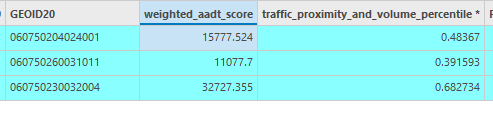